# Neural Network From Scratch using NumPy only

We will build a 2-layer MLP **from scratch** (NumPy only): forward pass, backprop, training loop, diagnostics.

**Target:** solve XOR and understand why linear models fail.


## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)


## 1) Data: XOR

In [2]:
X = np.array([[0.,0.],[0.,1.],[1.,0.],[1.,1.]], dtype=float)
y = np.array([[0.],[1.],[1.],[0.]], dtype=float)  # (N,1)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("X:\n", X)
print("y.T:\n", y.T)


X shape: (4, 2)
y shape: (4, 1)
X:
 [[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]
y.T:
 [[0. 1. 1. 0.]]


## 2) Activations

In [3]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def d_sigmoid(a):
    # a = sigmoid(z)
    return a * (1.0 - a)


## 3) Loss: Binary Cross-Entropy (with clipping)

In [4]:
def bce_loss(p, y, eps=1e-12):
    p = np.clip(p, eps, 1 - eps)
    return -np.mean(y*np.log(p) + (1-y)*np.log(1-p))


## 4) Baseline: Logistic Regression (will fail on XOR)

In [5]:
def train_logreg(X, y, lr=1.0, steps=5000, seed=0):
    rng = np.random.default_rng(seed)
    N, D = X.shape
    W = rng.normal(scale=0.1, size=(D, 1))
    b = np.zeros((1, 1))
    losses = []

    for t in range(steps):
        z = X @ W + b
        p = sigmoid(z)
        losses.append(bce_loss(p, y))

        # For BCE + sigmoid: dL/dz = (p - y)/N
        dZ = (p - y) / N
        dW = X.T @ dZ
        db = np.sum(dZ, axis=0, keepdims=True)

        W -= lr * dW
        b -= lr * db

    return W, b, np.array(losses)

In [6]:
W_lr, b_lr, losses_lr = train_logreg(X, y, lr=1.0, steps=5000, seed=1)

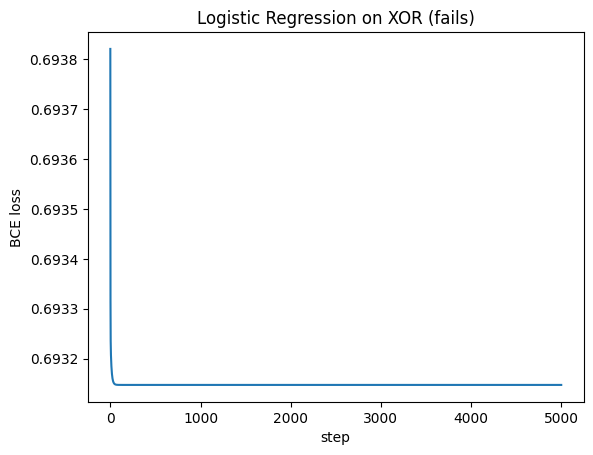

Pred probs: [[0.5 0.5 0.5 0.5]]
Pred labels: [[0 0 0 0]]


In [7]:
plt.figure()
plt.plot(losses_lr)
plt.title("Logistic Regression on XOR (fails)")
plt.xlabel("step")
plt.ylabel("BCE loss")
plt.show()

p_lr = sigmoid(X @ W_lr + b_lr)
print("Pred probs:", p_lr.T)
print("Pred labels:", (p_lr > 0.5).astype(int).T)


## 5) Two-layer MLP (2 → H → 1)

Hidden: `h = sigmoid(XW1 + b1)`
Output: `p = sigmoid(hW2 + b2)`


### 5.1 Parameter init

In [9]:
def init_params(D, H, seed=0):
    rng = np.random.default_rng(seed)
    W1 = rng.normal(scale=0.5, size=(D, H))
    b1 = np.zeros((1, H))
    W2 = rng.normal(scale=0.5, size=(H, 1))
    b2 = np.zeros((1, 1))
    return W1, b1, W2, b2

In [10]:
D, H = 2, 2
W1, b1, W2, b2 = init_params(D, H, seed=42)

In [11]:
print("W1", W1.shape, "b1", b1.shape, "W2", W2.shape, "b2", b2.shape)

W1 (2, 2) b1 (1, 2) W2 (2, 1) b2 (1, 1)


### 5.2 Forward pass (returns cache for backprop)

In [12]:
def forward_mlp(X, W1, b1, W2, b2):
    z1 = X @ W1 + b1   # (N,H)
    h  = sigmoid(z1)   # (N,H)
    z2 = h @ W2 + b2   # (N,1)
    p  = sigmoid(z2)   # (N,1)
    cache = (X, h, p)  # minimal cache
    return p, cache

In [13]:
p0, _ = forward_mlp(X, W1, b1, W2, b2)

In [14]:
print("Initial p:", p0.T)

Initial p: [[0.3072 0.2731 0.317  0.2827]]


### 5.3 Backprop gradients

With BCE + sigmoid output: `dZ2 = (p - y)/N`.


In [15]:
def backward_mlp(cache, y, W2):
    X, h, p = cache
    N = X.shape[0]

    dZ2 = (p - y) / N          # (N,1)
    dW2 = h.T @ dZ2            # (H,1)
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    dH  = dZ2 @ W2.T           # (N,H)
    dZ1 = dH * d_sigmoid(h)    # (N,H)
    dW1 = X.T @ dZ1            # (D,H)
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    return dW1, db1, dW2, db2

In [21]:
p, cache = forward_mlp(X, W1, b1, W2, b2)

In [22]:
dW1, db1, dW2, db2 = backward_mlp(cache, y, W2)

In [23]:
print("dW1", dW1.shape, "db1", db1.shape, "dW2", dW2.shape, "db2", db2.shape)

dW1 (2, 2) db1 (1, 2) dW2 (2, 1) db2 (1, 1)


## 6) Training loop (gradient descent)

In [24]:
def train_mlp(X, y, H=2, lr=1.0, steps=20000, seed=0, print_every=2500):
    N, D = X.shape
    W1, b1, W2, b2 = init_params(D, H, seed=seed)
    losses = []

    for t in range(steps):
        p, cache = forward_mlp(X, W1, b1, W2, b2)
        loss = bce_loss(p, y)
        losses.append(loss)

        dW1, db1, dW2, db2 = backward_mlp(cache, y, W2)

        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2

        if print_every and (t % print_every == 0 or t == steps-1):
            acc = np.mean(((p > 0.5).astype(int) == y.astype(int)))
            print(f"step={t:5d}  loss={loss:.6f}  acc={acc:.2f}")

    return (W1, b1, W2, b2), np.array(losses)

In [25]:
params, losses = train_mlp(X, y, H=2, lr=1.0, steps=20000, seed=2, print_every=2500)

step=    0  loss=0.744651  acc=0.50
step= 2500  loss=0.005696  acc=1.00
step= 5000  loss=0.002252  acc=1.00
step= 7500  loss=0.001398  acc=1.00
step=10000  loss=0.001013  acc=1.00
step=12500  loss=0.000793  acc=1.00
step=15000  loss=0.000652  acc=1.00
step=17500  loss=0.000553  acc=1.00
step=19999  loss=0.000481  acc=1.00


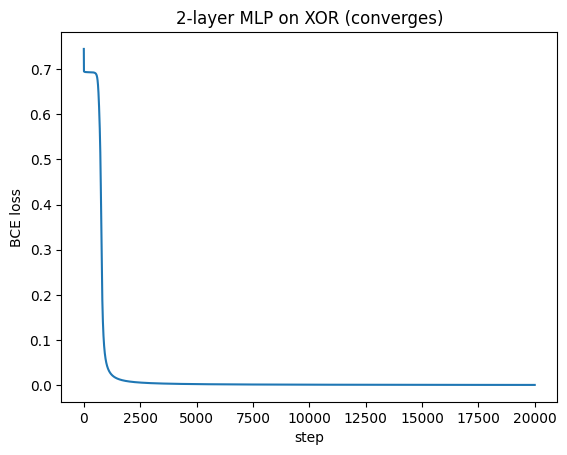

In [ ]:
plt.figure()
plt.plot(losses)
plt.title("2-layer MLP on XOR (converges)")
plt.xlabel("step")
plt.ylabel("BCE loss")
plt.show()

In [27]:
W1, b1, W2, b2 = params
p_final, _ = forward_mlp(X, W1, b1, W2, b2)
print("Final probs:", p_final.T)
print("Final preds:", (p_final > 0.5).astype(int).T)

Final probs: [[0.0006 0.9996 0.9996 0.0005]]
Final preds: [[0 1 1 0]]


## 7) Diagnostics: saturation and gradient norms

In [28]:
def train_mlp_with_diagnostics(X, y, H=2, lr=1.0, steps=12000, seed=0, diag_every=400):
    N, D = X.shape
    W1, b1, W2, b2 = init_params(D, H, seed=seed)

    losses = []
    grad_norms = []
    sat = []  # (min_h, max_h, mean_sigmoidprime)

    for t in range(steps):
        # forward
        z1 = X @ W1 + b1
        h  = sigmoid(z1)
        z2 = h @ W2 + b2
        p  = sigmoid(z2)

        losses.append(bce_loss(p, y))

        # backward
        dZ2 = (p - y) / N
        dW2 = h.T @ dZ2
        db2 = np.sum(dZ2, axis=0, keepdims=True)

        dH  = dZ2 @ W2.T
        dZ1 = dH * d_sigmoid(h)
        dW1 = X.T @ dZ1
        db1 = np.sum(dZ1, axis=0, keepdims=True)

        gn = np.sqrt(np.sum(dW1**2) + np.sum(dW2**2) + np.sum(db1**2) + np.sum(db2**2))
        grad_norms.append(float(gn))

        if t % diag_every == 0 or t == steps-1:
            sat.append((float(h.min()), float(h.max()), float(d_sigmoid(h).mean())))

        # update
        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2

    return (W1,b1,W2,b2), np.array(losses), np.array(grad_norms), np.array(sat)


In [29]:
_, losses_d, grad_norms_d, sat_stats = train_mlp_with_diagnostics(X, y, H=2, lr=1.0, steps=12000, seed=3, diag_every=400)

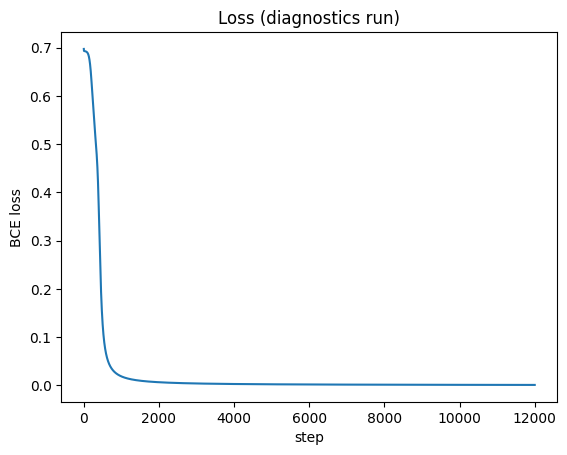

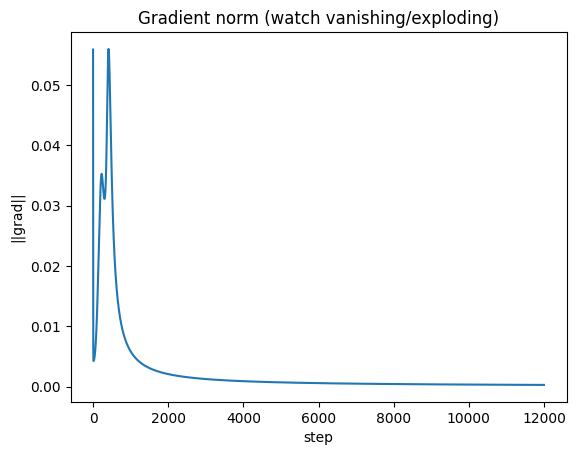

Saturation snapshots: [min(h), max(h), mean(sigmoid')]
[[0.1734 0.7737 0.2095]
 [0.0002 0.7505 0.122 ]
 [0.     0.9147 0.0481]]
...
[[0.     0.9652 0.0204]
 [0.     0.9655 0.0203]
 [0.     0.9657 0.0201]]


In [ ]:
plt.figure()
plt.plot(losses_d)
plt.title("Loss (diagnostics run)")
plt.xlabel("step")
plt.ylabel("BCE loss")
plt.show()

plt.figure()
plt.plot(grad_norms_d)
plt.title("Gradient norm (watch vanishing/exploding)")
plt.xlabel("step")
plt.ylabel("||grad||")
plt.show()

print("Saturation snapshots: [min(h), max(h), mean(sigmoid')]")
print(sat_stats[:3])
print("...")
print(sat_stats[-3:])

## 8) Numerical gradient check (one parameter)

Finite differences should roughly match analytic gradients.


In [31]:
def loss_from_params(X, y, W1, b1, W2, b2):
    p, _ = forward_mlp(X, W1, b1, W2, b2)
    return bce_loss(p, y)

In [32]:
def grad_check_one_param(X, y, W1, b1, W2, b2, which="W1", idx=(0,0), eps=1e-6):
    p, cache = forward_mlp(X, W1, b1, W2, b2)
    dW1, db1, dW2, db2 = backward_mlp(cache, y, W2)

    if which == "W1":
        analytic = dW1[idx]
        W1p = W1.copy(); W1p[idx] += eps
        W1m = W1.copy(); W1m[idx] -= eps
        numeric = (loss_from_params(X, y, W1p, b1, W2, b2) - loss_from_params(X, y, W1m, b1, W2, b2)) / (2*eps)
    elif which == "W2":
        analytic = dW2[idx]
        W2p = W2.copy(); W2p[idx] += eps
        W2m = W2.copy(); W2m[idx] -= eps
        numeric = (loss_from_params(X, y, W1, b1, W2p, b2) - loss_from_params(X, y, W1, b1, W2m, b2)) / (2*eps)
    else:
        raise ValueError("which must be 'W1' or 'W2' for this quick check")

    return float(analytic), float(numeric), float(abs(analytic - numeric))



In [33]:
# Check around freshly initialized params (harder) or trained params (usually tiny gradients)
W1, b1, W2, b2 = init_params(2, 2, seed=7)
a, n, d = grad_check_one_param(X, y, W1, b1, W2, b2, which="W1", idx=(0,0))
print("Check W1[0,0]: analytic=", a, " numeric=", n, " abs diff=", d)

Check W1[0,0]: analytic= 0.002480037998362561  numeric= 0.0024800380082901086  abs diff= 9.927547499344325e-12


In [34]:
a, n, d = grad_check_one_param(X, y, W1, b1, W2, b2, which="W2", idx=(0,0))
print("Check W2[0,0]: analytic=", a, " numeric=", n, " abs diff=", d)

Check W2[0,0]: analytic= -0.040739679587752056  numeric= -0.04073967957429758  abs diff= 1.3454473646312692e-11


## Key takeaways

- Linear models fail on XOR.
- Hidden layer + nonlinearity solves it.
- Backprop is chain rule through layers.
- Diagnostics prevent blind training.
